# Assignment 1: Supervised Learning

**Course:** Machine Learning Fundamentals

## General Instructions

1.  **Datasets**
    *   `server_performance_student.csv`: For regression analysis.
    *   `fraud_detection_student.csv`: For classification analysis.

🔹 **Assignment Breakdown:**
| Task | Description | Points |
|------|------------|--------|
| **Task 1.1** | Linear and Polynomial Regression | 30 |
| **Task 2.1** | Data Preprocessing | 20 |
| **Task 2.2** | Classificaiton | 30 |
| **Task 2.3** | Thresholding | 20 |
| **Total** | - | **100** |

---
## Required Libraries

In [24]:
import pandas as pd
import numpy as np
from typing import Dict, Tuple, Any

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import f1_score, recall_score, precision_score

# GLOBAL RANDOM STATE
RANDOM_STATE = 2026

# Added by me
import matplotlib.pyplot as plt

## Task 1: Regression

**Objective:** Predict server latency based on concurrent requests.

**Requirements:**
1.  Load `server_performance_student.csv`.
2.  Use `random_state=2026` to split dataset.
3.  Train a **Linear Regression** model.
4.  Plot the data to analyze and see why your Linear model fail?
4.  Train a **Polynomial Regression** model to find the optimal degree (search range: 2 to 5).
5.  Return the metrics in the dictionary format specified below.

In [26]:
def task1_regression(df: pd.DataFrame) -> Dict[str, Any]:

    # Preparing data
    X = df[['Concurrent_Requests']]
    y = df['Latency_ms']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=2026
    )

    # Linear regression
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)

    y_pred_linear = linear_model.predict(X_test)

    linear_mse = mean_squared_error(y_test, y_pred_linear)
    linear_rmse = np.sqrt(linear_mse)
    linear_mae = mean_absolute_error(y_test, y_pred_linear)
    linear_r2 = r2_score(y_test, y_pred_linear)

    linear_metrics = {
        'mse': linear_mse,
        'rmse': linear_rmse,
        'mae': linear_mae,
        'r2': linear_r2
    }

    # Plotting linear regression
    plt.figure(figsize=(8, 5))
    plt.scatter(X_test, y_test, color='black', label='Actual')

    x_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    plt.plot(x_range, linear_model.predict(x_range),
             color='red', label='Linear fit')

    plt.xlabel("Concurrent Requests")
    plt.ylabel("Latency (ms)")
    plt.title("Linear Regression Fit (Fails on Nonlinear Data)")
    plt.legend()
    plt.show()

    # Polynomial Regression
    pipe = Pipeline([
        ('poly', PolynomialFeatures(include_bias=False)),
        ('lin', LinearRegression())
    ])

    param_grid = {
        'poly__degree': [2, 3, 4, 5]
    }

    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring='neg_root_mean_squared_error',
        cv=5
    )

    grid.fit(X_train, y_train)

    best_poly_model = grid.best_estimator_
    best_degree = grid.best_params_['poly__degree']

    y_pred_poly = best_poly_model.predict(X_test)

    poly_mse = mean_squared_error(y_test, y_pred_poly)
    poly_rmse = np.sqrt(poly_mse)
    poly_mae = mean_absolute_error(y_test, y_pred_poly)
    poly_r2 = r2_score(y_test, y_pred_poly)

    poly_metrics = {
        'mse': poly_mse,
        'rmse': poly_rmse,
        'mae': poly_mae,
        'r2': poly_r2
    }

    # Plot polynomial regression
    plt.figure(figsize=(8, 5))
    plt.scatter(X_test, y_test, color='black', label='Actual')

    plt.plot(x_range, best_poly_model.predict(x_range),
             color='blue', label=f'Polynomial degree {best_degree}')

    plt.xlabel("Concurrent Requests")
    plt.ylabel("Latency (ms)")
    plt.title("Polynomial Regression Fit")
    plt.legend()
    plt.show()


    # Result
    return {
        'linear_model': linear_model,
        'linear_metrics': linear_metrics,
        'poly_model': best_poly_model,
        'poly_degree': best_degree,
        'poly_metrics': poly_metrics
    }

## Task 2: Classification

### Task 2.1: Data Preprocessing

**Objective:** Clean and prepare the `fraud_detection_student.csv` dataset.

**Requirements:**
1.  **Leakage Removal:** Identify and drop the column that represents data leakage (information available only after fraud determination).
2.  **Feature Engineering:** Create a new binary feature `is_high_risk` from `IP_Address` (1 if starts with `192.168.0`, else 0). Drop original IP column.
3.  Use `random_state=2026` and `stratify` to split data.
4.  **Scaling:** Apply `StandardScaler`.
5.  **Output:** Return the processed numpy arrays.

In [31]:
def task2_preprocessing(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    # Target to predict
    y = df['Is_Fraud']

    # Drop leakage columm
    df = df.drop(['Is_Fraud', 'Transaction_ID'], axis=1)

    # Feature engeneering
    df['is_high_risk'] = df['IP_Address'].astype(str).apply(
        lambda x: 1 if x.startswith('192.168.0') else 0
    )

    df = df.drop(['IP_Address', 'Transaction_Status'], axis=1)
    X = df

    # Splitting
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=2026,
        stratify=y
    )

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    return X_train_scaled, X_test_scaled, y_train.to_numpy(), y_test.to_numpy()

### Task 2.2: Model Training

**Objective:** Train three classifiers to detect fraud and compare their performance.

**Instructions:**
1.  Use the `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test` variables returned from Task 2.1.
2.  **Logistic Regression:** Use `class_weight='balanced'` to handle class imbalace.
3.  **K-Nearest Neighbors:** Tune `n_neighbors` (3-9). Use `weights='distance'` to handle class imbalace.
4.  **Naive Bayes:** Use `priors=[0.5, 0.5]` to handle class imbalace.
5.  Evaluate all models using **F1-Score at default threshold (0.5)**.
6.  Return all three trained models and their F1 scores.

In [32]:
def task2_train_models(X_train: np.ndarray, X_test: np.ndarray, y_train: np.ndarray, y_test: np.ndarray) -> Tuple[Dict[str, Any], Dict[str, Any]]:

    # Logistic Regression
    logreg = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=2026
    )
    logreg.fit(X_train, y_train)

    logreg_pred = logreg.predict(X_test)
    logreg_f1 = f1_score(y_test, logreg_pred)

    # KNN with GridSearchCV
    knn = KNeighborsClassifier(weights='distance')
    param_grid = {
        'n_neighbors': list(range(3, 10))
    }

    grid = GridSearchCV(
        knn,
        param_grid,
        scoring='f1',
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    knn_best = grid.best_estimator_

    knn_pred = knn_best.predict(X_test)
    knn_f1 = f1_score(y_test, knn_pred)

    # Naive Bayes
    nb = GaussianNB(priors=[0.5, 0.5])
    nb.fit(X_train, y_train)

    nb_pred = nb.predict(X_test)
    nb_f1 = f1_score(y_test, nb_pred)

    # Return
    models = {
        'logreg': logreg,
        'knn': knn_best,
        'nb': nb
    }

    metrics = {
        'logreg_f1': logreg_f1,
        'knn_f1': knn_f1,
        'nb_f1': nb_f1
    }

    return models, metrics

### Task 2.3: Threshold Tuning for Logistic Regression

**Objective:** Improve Logistic Regression performance through threshold optimization.

**Context:** You may have noticed that Logistic Regression had the lowest F1-score at the default threshold (0.5) but for imbalanced datasets like fraud detection, the decision threshold can significantly impact performance.

**Instructions:**
1.  Take the Logistic Regression model from Task 2.2.
2.  Predict probabilities on the Test Set.
3.  Iterate through different thresholds (based on your decision) to find the one that maximizes F1-Score.
4.  Return the optimal threshold and the improved F1-Score.

In [33]:
def task2_threshold_tuning(logreg_model: Any, X_test: np.ndarray, y_test: np.ndarray) -> Dict[str, float]:

    probs = logreg_model.predict_proba(X_test)[:, 1]

    best_threshold = 0
    best_f1 = 0

    for threshold in np.linspace(0.01, 0.99, 99):
        y_pred = (probs >= threshold).astype(int)
        f1 = f1_score(y_test, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    return {'best_threshold': best_threshold, 'optimized_f1': best_f1}

# Pretty printing!!

===== Task 1: Regression =====


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


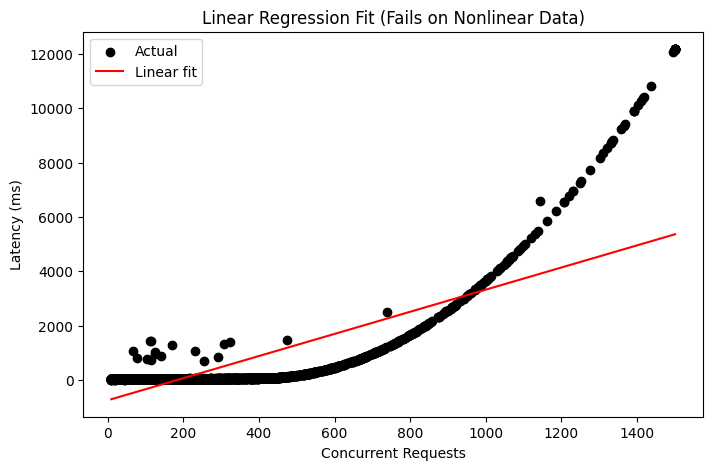

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


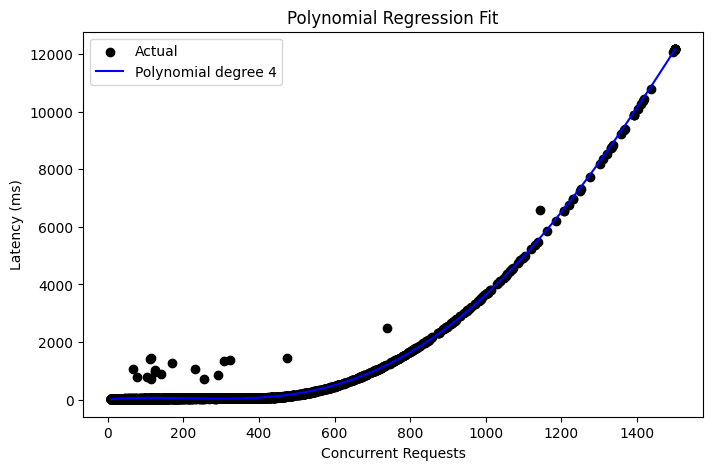

Linear Regression RMSE : 968.0789905579064
Polynomial Regression RMSE (deg=4): 103.52662636159098

===== Task 2.1: Preprocessing =====
Train shape: (8000, 3) Test shape: (2000, 3)

===== Task 2.2: Model Training =====
Logistic Regression F1 (0.5) : 0.44878048780487806
KNN F1 (0.5)                 : 0.6349206349206349
Naive Bayes F1 (0.5)          : 0.5874125874125874

===== Task 2.3: Threshold Tuning =====
Optimal threshold : 0.99
Optimized F1       : 0.6507936507936508


In [36]:
# Load datasets
server_df = pd.read_csv('server_performance_student.csv')
fraud_df = pd.read_csv('fraud_detection_student.csv')

# ---------- Task 1 ----------
print("===== Task 1: Regression =====")
res1 = task1_regression(server_df)
print("Linear Regression RMSE :", res1['linear_metrics']['rmse'])
print("Polynomial Regression RMSE (deg={}):".format(res1['poly_degree']), res1['poly_metrics']['rmse'])

# ---------- Task 2.1 ----------
print("\n===== Task 2.1: Preprocessing =====")
X_train, X_test, y_train, y_test = task2_preprocessing(fraud_df)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# ---------- Task 2.2 ----------
print("\n===== Task 2.2: Model Training =====")
models, metrics = task2_train_models(X_train, X_test, y_train, y_test)
print("Logistic Regression F1 (0.5) :", metrics['logreg_f1'])
print("KNN F1 (0.5)                 :", metrics['knn_f1'])
print("Naive Bayes F1 (0.5)          :", metrics['nb_f1'])

# ---------- Task 2.3 ----------
print("\n===== Task 2.3: Threshold Tuning =====")
opt = task2_threshold_tuning(models['logreg'], X_test, y_test)
print("Optimal threshold :", opt['best_threshold'])
print("Optimized F1       :", opt['optimized_f1'])